In [1]:

pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Taylor_Train.csv", encoding="latin1")

In [4]:
df[['Tickets sold', 'Tickets available']] = df['Attendance (tickets sold / available)'].str.split('/', expand=True)

In [5]:
df = df.drop('Attendance (tickets sold / available)', axis=1)


In [6]:
df['Revenue'] = df['Revenue'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['Tickets sold'] = df['Tickets sold'].str.replace(',', '', regex=False)
df['Tickets available'] = df['Tickets available'].str.replace(',', '', regex=False)

In [7]:
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')
df['Tickets sold'] = pd.to_numeric(df['Tickets sold'], errors='coerce')
df['Tickets available'] = pd.to_numeric(df['Tickets available'], errors='coerce')

In [8]:
df['Tickets remaining'] = df['Tickets available'] - df['Tickets sold']

In [9]:
df['Opening act(s)'] = df['Opening act(s)'].fillna('No opening acts')

In [10]:
df['Opening act(s)'] = df['Opening act(s)'].str.replace('\r\n', ' and ', regex=False).str.replace('&', ' and ', regex=False)

In [11]:
df['Number of opening acts'] = df['Opening act(s)'].apply(lambda x: 0 if 'No' in str(x) else 1 if 'and' not in str(x) else str(x).count('and') + 1)

In [12]:
df['Revenue'] = df['Revenue'].fillna(df['Revenue'].mean())
df['Tickets sold'] = df['Tickets sold'].fillna(df['Tickets sold'].mean())
df['Tickets available'] = df['Tickets available'].fillna(df['Tickets available'].mean())
df['Tickets remaining'] = df['Tickets remaining'].fillna(df['Tickets remaining'].mean())

In [13]:
df = df.drop_duplicates().reset_index(drop=True)

In [14]:
display(df.describe())

,Revenue,Tickets sold,Tickets available,Tickets remaining,Number of opening acts
count,3.330000e+02,333.000000,333.000000,333.000000,333.000000
mean,3.233391e+06,33049.325689,33112.244608,62.918919,1.597598
std,3.498796e+06,28768.654066,28752.787654,651.882647,0.581020
min,1.533030e+05,3421.000000,3962.000000,0.000000,0.000000
25%,8.969460e+05,13373.000000,13373.000000,0.000000,1.000000
50%,1.870471e+06,25663.000000,25663.000000,0.000000,2.000000
75%,3.892357e+06,38954.904177,39002.093366,0.000000,2.000000
max,2.203139e+07,174764.000000,174764.000000,10590.000000,3.000000


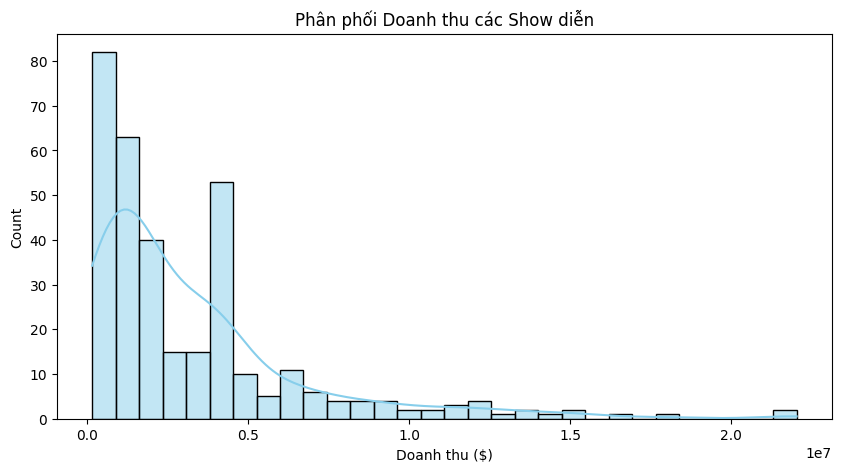

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Revenue'], bins=30, kde=True, color='skyblue')
plt.title('Phân phối Doanh thu các Show diễn')
plt.xlabel('Doanh thu ($)')
plt.show()

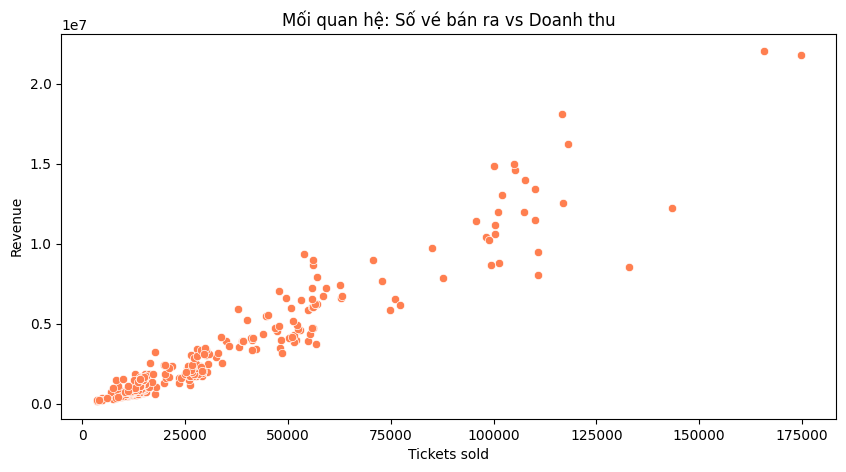

In [16]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Tickets sold', y='Revenue', data=df, color='coral')
plt.title('Mối quan hệ: Số vé bán ra vs Doanh thu')
plt.show()

C:\Users\NguyenDung\AppData\Local\Temp\ipykernel_19188\3618495038.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette='viridis')


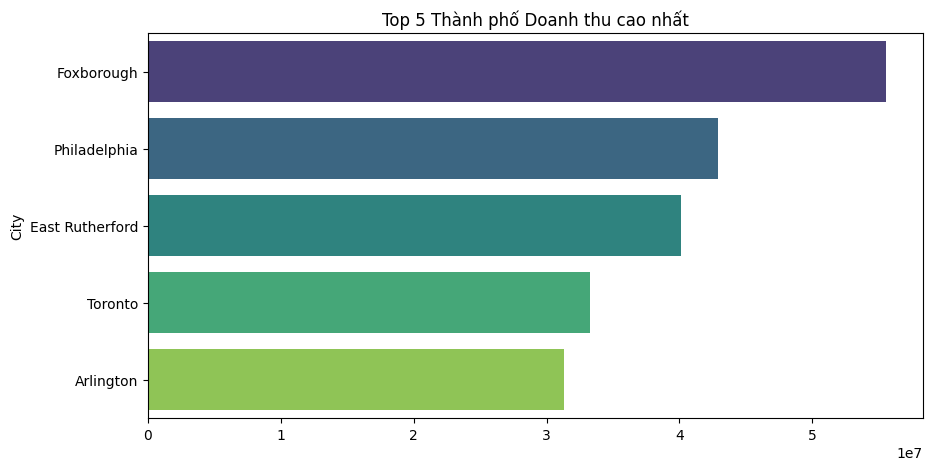

In [17]:
top_cities = df.groupby('City')['Revenue'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_cities.values, y=top_cities.index, palette='viridis')
plt.title('Top 5 Thành phố Doanh thu cao nhất')
plt.show()

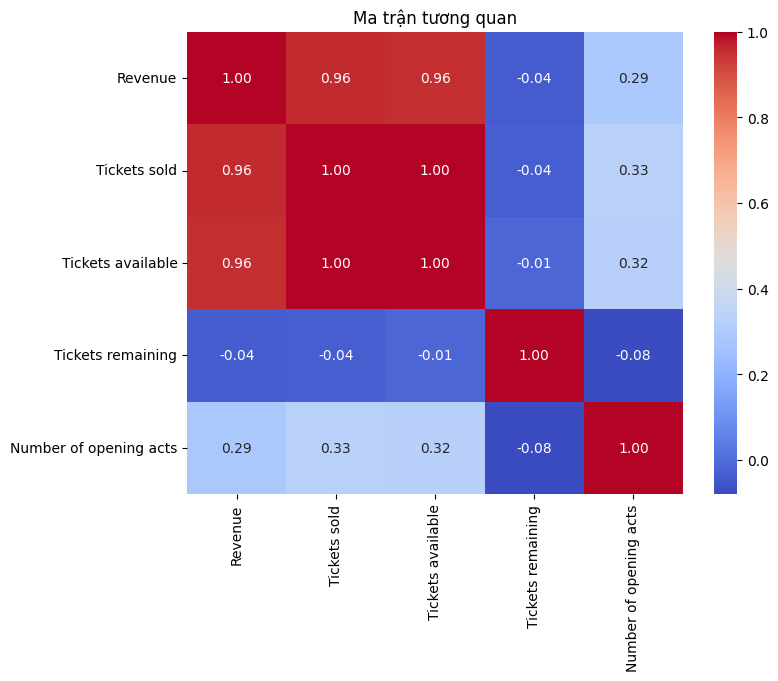

In [18]:
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan')
plt.show()